# 用朴素贝叶斯模型对Yelp网站的评论文本进行分类

## 第一步：读入数据

把`yelp.csv`读入一个DataFrame中。

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [54]:
# read csv
# 把`yelp.csv`读入一个DataFrame中
url = "yelp.csv"
yelp = pd.read_csv(url)
yelp.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


创建一个新的DataFrame，只包含5颗星和1颗星评分的数据。

In [32]:
# filter data
# 筛选出星级为1或5的评论
yelp_1_5 = yelp[yelp['stars'].isin([1, 5])]
print("筛选后的数据形状：", yelp_1_5.shape)

筛选后的数据形状： (4086, 10)


## 第二步：生成X和y

使用评论文本作为唯一的分类特征，评分星数作为预测目标，并将数据集划分为训练集和测试集。

In [33]:
# define X and y
# split into training and testing sets
X = yelp_1_5['text']
y = yelp_1_5['stars']

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print("训练集样本数：", len(X_train))
print("测试集样本数：", len(X_test))

训练集样本数： 3268
测试集样本数： 818


## 第三步：转换数据

使用CountVectorizer将X_train和X_test转换为document-term矩阵。

In [34]:
# import and instantiate the vectorizer
# fit and transform X_train, but only transform X_test
# 使用CountVectorizer将X_train和X_test转换为document - term矩阵
vect = CountVectorizer()
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)
print("训练集矩阵形状：", X_train_dtm.shape)
print("测试集矩阵形状：", X_test_dtm.shape)

训练集矩阵形状： (3268, 17342)
测试集矩阵形状： (818, 17342)


## 第四步：训练、预测、评价

使用朴素贝叶斯预测测试集中评论的星级评分，并计算预测精度。

In [35]:
# import/instantiate/fit
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

MultinomialNB()

In [36]:
# make class predictions
y_pred_class = nb.predict(X_test_dtm)

In [37]:
# calculate accuracy
accuracy = metrics.accuracy_score(y_test, y_pred_class)
print("预测精度：", round(accuracy, 4))

预测精度： 0.9315


计算AUC。注意：y_test中的取值是1和5，需要先把它转换为取值为0和1的二值数组y_test_binary。

In [38]:
# create y_test_binary from y_test, which contains ones and zeros instead
y_test_binary = (y_test == 5).astype(int)

In [39]:
# predict class probabilities
y_pred_prob = nb.predict_proba(X_test_dtm)[:, 1]

In [40]:
# calculate the AUC using y_test_binary and y_pred_prob
auc = metrics.roc_auc_score(y_test_binary, y_pred_prob)
print("AUC：", round(auc, 4))

AUC： 0.9562


绘制ROC曲线。

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

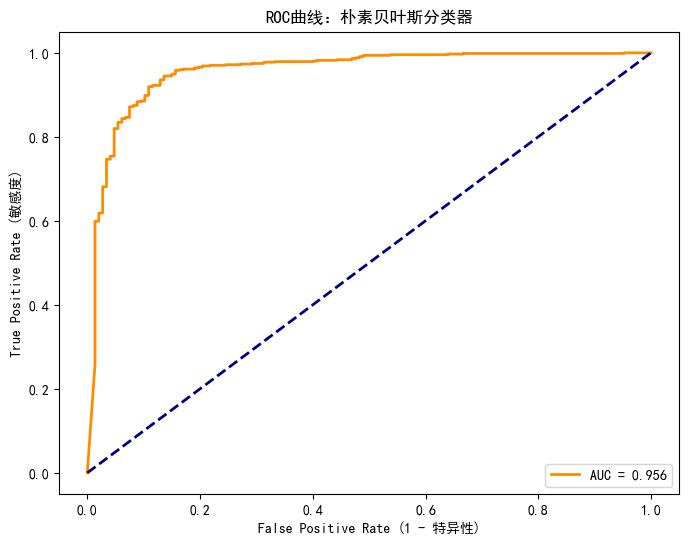

In [42]:
# plot ROC curve using y_test_binary and y_pred_prob
fpr, tpr, thresholds = metrics.roc_curve(y_test_binary, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {round(auc, 3)}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - 特异性)')
plt.ylabel('True Positive Rate (敏感度)')
plt.title('ROC曲线：朴素贝叶斯分类器')
plt.legend(loc='lower right')
plt.show()

显示混淆矩阵，并计算敏感度和特异性，评论结果。

In [43]:
# print the confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
print("混淆矩阵：")
print("          预测为1星  预测为5星")
print(f"真实1星:  {cm[0, 0]}          {cm[0, 1]}")
print(f"真实5星:  {cm[1, 0]}          {cm[1, 1]}")

混淆矩阵：
          预测为1星  预测为5星
真实1星:  110          37
真实5星:  19          652


In [44]:
# calculate sensitivity
# calculate specificity
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"敏感度（识别5星的能力）：{round(sensitivity, 4)}")
print(f"特异性（识别1星的能力）：{round(specificity, 4)}")

敏感度（识别5星的能力）：0.9717
特异性（识别1星的能力）：0.7483


对模型的敏感度和特异性做出评论：在识别五星评论不错，识别一星评论的能力有待提高

## 第五步：错误分析

查看测试集中一些被预测错误的评论文本，即false positives和false negatives。试着回答为什么这些评论会被预测错。

In [45]:
# first 10 false positives (meaning they were incorrectly classified as 5-star reviews)
false_positives = X_test[(y_test == 1) & (y_pred_class == 5)].head(10)
print("前10条假正例评论：")
print(false_positives)

前10条假正例评论：
1781    If you like the stuck up Scottsdale vibe this ...
9984    Went last night to Whore Foods to get basics t...
995     Not worth the money. Food was average and the ...
3392    I found Lisa G's while driving through phoenix...
2765    Went last week, and ordered a dozen variety. I...
2839    Never Again,\nI brought my Mountain Bike in (w...
321     My wife and I live around the corner, hadn't e...
1919                                         D-scust-ing.
2490    Lazy Q CLOSED in 2010.  New Owners cleaned up ...
8755    Not lesbian/gay friendly at all. I should have...
Name: text, dtype: object


In [46]:
# first 10 false negatives (meaning they were incorrectly classified as 1-star reviews)
false_negatives = X_test[(y_test == 5) & (y_pred_class == 1)].head(10)
print("前10条假负例评论：")
print(false_negatives)

前10条假负例评论：
7148    I now consider myself an Arizonian. If you dri...
4963    This is by far my favourite department store, ...
6318    Since I have ranted recently on poor customer ...
380     This is a must try for any Mani Pedi fan. I us...
5565    I`ve had work done by this shop a few times th...
3448    I was there last week with my sisters and whil...
6050    I went to sears today to check on a layaway th...
2504    I've passed by prestige nails in walmart 100s ...
2475    This place is so great! I am a nanny and had t...
241     I was sad to come back to lai lai's and they n...
Name: text, dtype: object


## 第六步：多分类预测

使用所有的评论做预测，而不仅仅是评分1星和5星的评论。

In [47]:
# define X and y using the original DataFrame
X_all = yelp['text']
y_all = yelp['stars']

In [48]:
# split into training and testing sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, random_state=1)

In [49]:
# create document-term matrices
vect_all = CountVectorizer()
X_train_all_dtm = vect_all.fit_transform(X_train_all)
X_test_all_dtm = vect_all.transform(X_test_all)

In [50]:
# fit a Naive Bayes model
nb_all = MultinomialNB()
nb_all.fit(X_train_all_dtm, y_train_all)

MultinomialNB()

In [51]:
# make class predictions
y_pred_all = nb_all.predict(X_test_all_dtm)

In [52]:
# calculate the testing accuary
accuracy_all = metrics.accuracy_score(y_test_all, y_pred_all)
print(f"多分类预测精度：{round(accuracy_all, 4)}")

多分类预测精度：0.478


In [53]:
# print the confusion matrix
cm_all = confusion_matrix(y_test_all, y_pred_all)
print("多分类混淆矩阵：")
print("预测星级 | 1  2  3  4  5")
print("---------------------------------")
for i in range(5):
    print(f"真实{i + 1}星 | {' '.join(map(str, cm_all[i]))}")

多分类混淆矩阵：
预测星级 | 1  2  3  4  5
---------------------------------
真实1星 | 41 16 20 51 19
真实2星 | 21 16 31 98 20
真实3星 | 8 5 27 220 28
真实4星 | 5 0 17 516 168
真实5星 | 6 3 8 300 356


有何评论：多分类预测精度为 0.478，表现欠佳，混淆矩阵也显示各星级存在较多误判，比如分不清4和5星